In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm

In [2]:
data = pd.read_excel(r'F:\StudyBuilt\ali-ashrafi\data\processed\cleaned_dataset_ali_ashrafi.xlsx')

In [3]:
df = data.copy(deep=True)

In [4]:
print("ابعاد دیتاست:", df.shape) 
print("تعداد رکوردهای تکراری:", df.duplicated().sum()) 
print("مقادیر گمشده هر ستون:") 
print(df.isna().sum().sort_values(ascending=False)) 
  
display(df.head())    

ابعاد دیتاست: (60, 19)
تعداد رکوردهای تکراری: 0
مقادیر گمشده هر ستون:
customer_id           0
total_spending        0
needs_review          0
satisfaction_score    0
returned_items        0
discount_used         0
device                0
payment_method        0
last_purchase_days    0
avg_order_value       0
first_name            0
purchase_count        0
membership_tier       0
signup_date           0
province              0
city                  0
age                   0
gender                0
review_reason         0
dtype: int64


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,needs_review,review_reason
0,1001,Reza,M,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5,False,Approved
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,False,Approved
2,1003,Parsa,M,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,False,Approved
3,1004,Sina,M,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,False,Approved
4,1005,Kimia,F,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,False,Approved


## سوال 1 : مشتریان اصلی فروشگاه چه کسانی هستند ؟

In [5]:
# Age Group Segmentation

bins = [19, 31, 43, 55, np.inf]
df['age_group'] = pd.cut (df['age'], bins, labels=['19-31', '32-43', '44-55', '56+'] , include_lowest=True)

In [6]:
# report customer summary

customer_summary1 = pd.DataFrame ({
    'number of customer' : df['customer_id'].nunique(),
    'avg_age' : df['age'].mean().round(),
    'mode_gender' : df['gender'].mode(),
    'mode_group_age' : df['age_group'].mode(),
    'mode_tier' : df['membership_tier'].mode(),
    'mode_device' : df['device'].mode(),
    'mode_payment_method' : df['payment_method'].mode() })

customer_summary1.head()

,number of customer,avg_age,mode_gender,mode_group_age,mode_tier,mode_device,mode_payment_method
0,60,44.0,M,56+,Gold,Android,Online Wallet


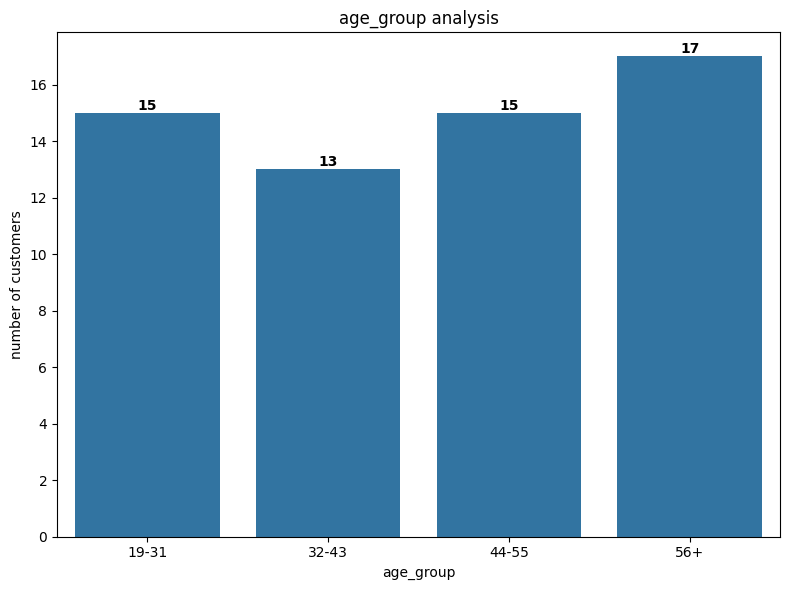

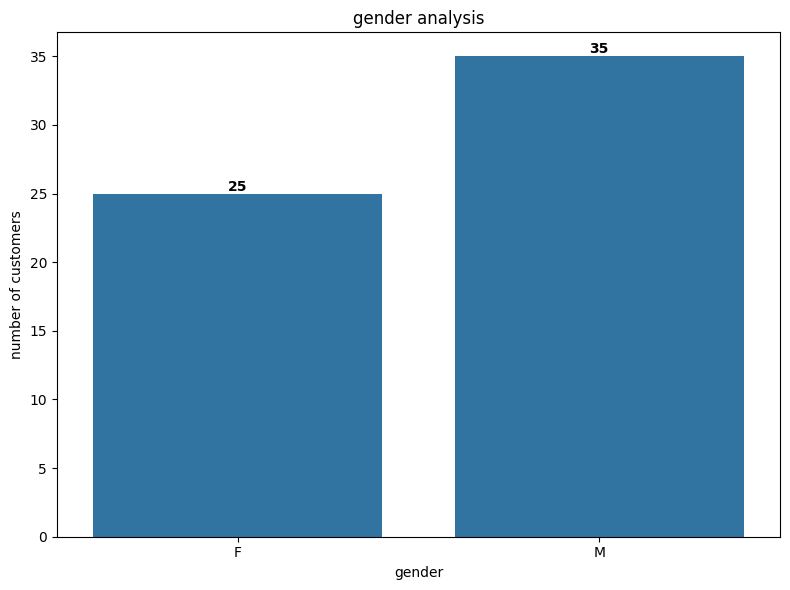

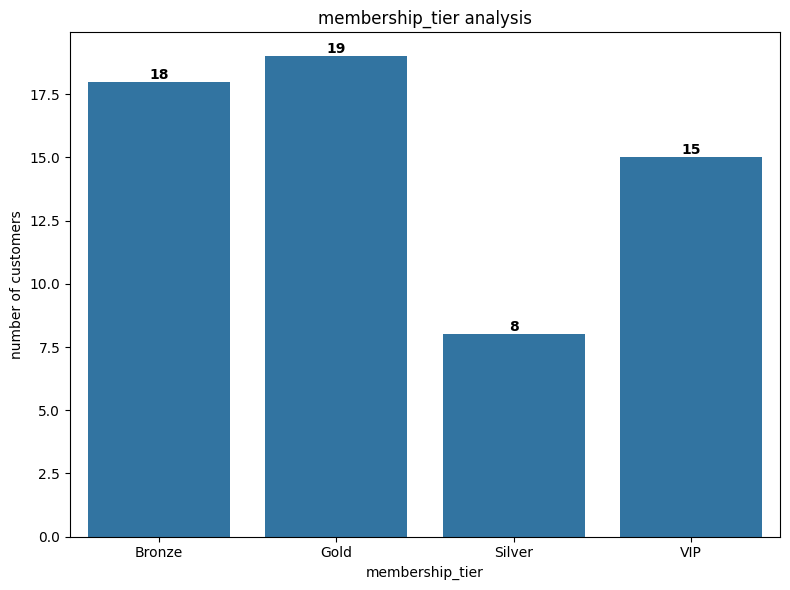

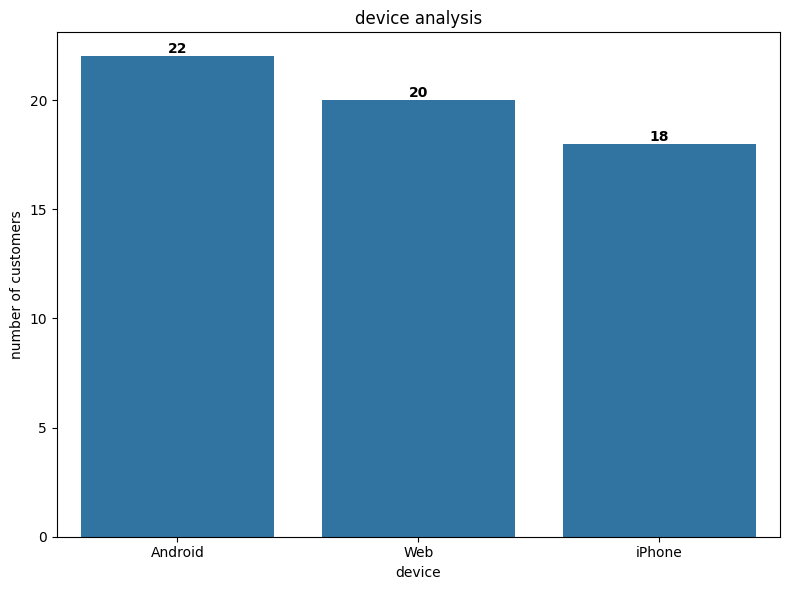

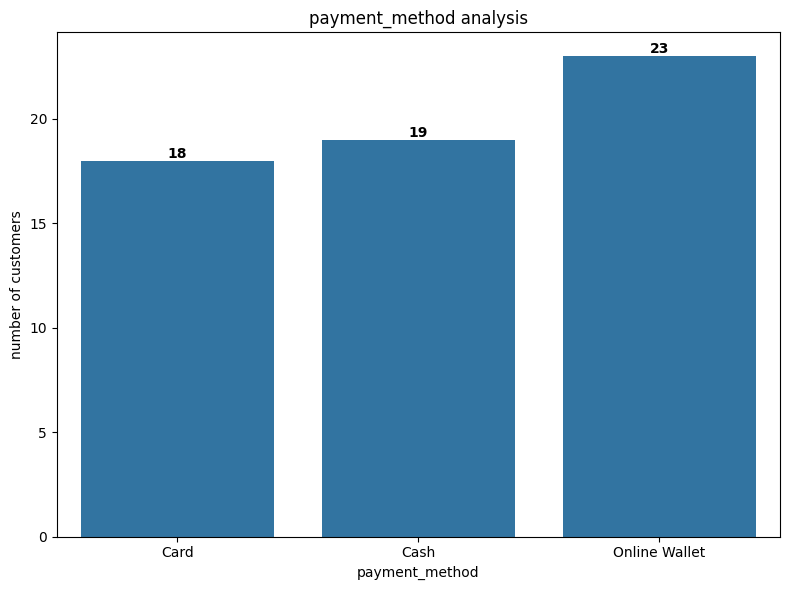

In [7]:
# Customer Profile Overview

cols = ['age_group', 'gender', 'membership_tier', 'device', 'payment_method']

for col in cols :
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
    sns.countplot(data=df, x=df[col].sort_values())
    ax.set(title=f'{col} analysis' ,xlabel=col ,ylabel="number of customers")

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',(p.get_x()+p.get_width()/2, p.get_height()),
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
        fontweight = 'bold')
    
    plt.tight_layout()
    plt.show()
    print(3*'\n')


## سوال 2 : کدام استان و شهر برای سرمایه گذاری تبلیغاتی مناسب تر است ؟

In [99]:
# analysis customers by city

city_summary = df.groupby(['province', 'city'], as_index=False).agg(

    total_spending_city = ('total_spending', 'sum'),
    purchase_count_city = ('purchase_count', 'sum'),
    number_of_customers_city = ('customer_id', 'nunique'),
    most_membership_tier_city = ('membership_tier', lambda x: x.mode()[0]),
    avg_last_purchase_days_city = ('last_purchase_days', 'mean'),
    avg_returned_items = ('returned_items', 'mean'),
    avg_satisfaction_city = ('satisfaction_score', 'mean'))

city_summary['ARPU_city'] = city_summary['total_spending_city'] / city_summary['number_of_customers_city']

city_summary.sort_values(by='ARPU_city', ascending=False).reset_index(drop=True)

,province,city,total_spending_city,purchase_count_city,number_of_customers_city,most_membership_tier_city,avg_last_purchase_days_city,avg_returned_items,avg_satisfaction_city,ARPU_city
0,Isfahan,Isfahan,21975.32,99,5,Bronze,177.200000,4.400000,4.400000,4395.064000
1,Khorasan,Mashhad,43197.58,249,11,Gold,213.636364,2.636364,2.909091,3927.052727
2,Alborz,Karaj,26189.81,112,7,Bronze,166.000000,4.857143,2.857143,3741.401429
3,Fars,Shiraz,20715.92,98,6,Gold,214.666667,4.833333,2.000000,3452.653333
4,Gilan,Rasht,15168.54,82,5,Bronze,185.800000,4.400000,2.600000,3033.708000
5,East Azerbaijan,Tabriz,36192.49,189,12,VIP,227.250000,4.583333,3.000000,3016.040833
6,Khuzestan,Ahvaz,23384.78,111,8,Gold,171.000000,4.875000,3.500000,2923.097500
7,Tehran,Tehran,15161.29,103,6,Gold,201.000000,3.500000,2.666667,2526.881667


In [100]:
print('avg_satisfaction_score', df['satisfaction_score'].mean())
print('avg_last_purchase_days', df['last_purchase_days'].mean())
print('avg_returned_items', df['returned_items'].mean())
print('total_spending', df['total_spending'].sum())

avg_satisfaction_score 2.9833333333333334
avg_last_purchase_days 198.6
avg_returned_items 4.183333333333334
total_spending 201985.72999999998


In [66]:
overall_avg_spending = (df['total_spending'].sum() / df['customer_id'].nunique())
print('overall_avg_spending :', overall_avg_spending.round(2), 2*'\n')
city_summary['spending_vs_overall_pct'] = ((city_summary['ARPU_city'] / overall_avg_spending - 1) * 100)
city_summary[['city','ARPU_city','spending_vs_overall_pct']].sort_values(by='spending_vs_overall_pct', ascending=False)

overall_avg_spending : 3366.43 




,city,ARPU_city,spending_vs_overall_pct
4,Isfahan,4395.064000,30.555678
5,Mashhad,3927.052727,16.653371
0,Karaj,3741.401429,11.138587
2,Shiraz,3452.653333,2.561305
3,Rasht,3033.708000,-9.883495
1,Tabriz,3016.040833,-10.408300
6,Ahvaz,2923.097500,-13.169188
7,Tehran,2526.881667,-24.938806


In [68]:
# City Ranking by ARPU score

q25, q50, q85, q100 = city_summary['ARPU_city'].quantile([0.25, 0.50, 0.85, 1])

conditions = [
    city_summary['ARPU_city'] <= q25,
    city_summary['ARPU_city'] <= q50,
    city_summary['ARPU_city'] <= q85,
    city_summary['ARPU_city'] > q85]

labels = ['low', 'medium', 'high', 'very_high']
city_summary['arpu_city_status'] = np.select(conditions, labels, default='unknown')


arpu_map = {
    'low' : 0.5,
    'medium' : 0.7,
    'high' : 0.9,
    'very_high' : 1}
city_summary['arpu_city_score'] = city_summary['arpu_city_status'].map(arpu_map)

print(14*'--')
print('City Ranking by ARPU_city score')
print(14*'--', '\n')

city_summary[['city', 'ARPU_city', 'arpu_city_status', 'total_spending_city', 'number_of_customers_city', 'avg_satisfaction_city',
              'arpu_city_score']].sort_values(by='number_of_customers_city', ascending=False).reset_index(drop=True)

----------------------------
City Ranking by ARPU_city score
---------------------------- 



,city,ARPU_city,arpu_city_status,total_spending_city,number_of_customers_city,avg_satisfaction_city,arpu_city_score
0,Tabriz,3016.040833,medium,36192.49,12,3.000000,0.7
1,Mashhad,3927.052727,very_high,43197.58,11,2.909091,1.0
2,Ahvaz,2923.097500,low,23384.78,8,3.500000,0.5
3,Karaj,3741.401429,high,26189.81,7,2.857143,0.9
4,Shiraz,3452.653333,high,20715.92,6,2.000000,0.9
5,Tehran,2526.881667,low,15161.29,6,2.666667,0.5
6,Rasht,3033.708000,medium,15168.54,5,2.600000,0.7
7,Isfahan,4395.064000,very_high,21975.32,5,4.400000,1.0


In [72]:
isfahan_customer_share = 5 / df["customer_id"].nunique() * 100
isfahan_customer_share

8.333333333333332

In [11]:
# City Ranking by satisfaction score

q25, q50, q90, q100 = city_summary['avg_satisfaction_city'].quantile([0.25, 0.5, 0.9, 1])

conditions = [
    city_summary['avg_satisfaction_city'].lt(q25),
    city_summary['avg_satisfaction_city'].between(q25, q50, inclusive='left'),
    city_summary['avg_satisfaction_city'].between(q50, q90, inclusive='left'),
    city_summary['avg_satisfaction_city'].ge(q90)]

labels = ['Dissatisfied','Somewhat_Satisfied', 'Satisfied', 'Very_Satisfied']

city_summary['satisfaction_city_status'] = np.select(conditions, labels, default='unknwon')

satisfaction_map = {
    'Dissatisfied' : 0.4,
    'Somewhat_Satisfied' : 0.6,
    'Satisfied' : 0.8,
    'Very_Satisfied' : 1}

city_summary['satisfaction_city_score'] = city_summary['satisfaction_city_status'].map(satisfaction_map)


print(20*'--')
print('City Ranking by satisfaction_city score')
print(20*'--', '\n')


city_summary[['city', 'avg_satisfaction_city', 'satisfaction_city_status', 
              'satisfaction_city_score']].sort_values(by='satisfaction_city_score',  ascending=False).reset_index(drop=True)    

----------------------------------------
City Ranking by satisfaction_city score
---------------------------------------- 



,city,avg_satisfaction_city,satisfaction_city_status,satisfaction_city_score
0,Isfahan,4.400000,Very_Satisfied,1.0
1,Tabriz,3.000000,Satisfied,0.8
2,Mashhad,2.909091,Satisfied,0.8
3,Ahvaz,3.500000,Satisfied,0.8
4,Karaj,2.857143,Somewhat_Satisfied,0.6
5,Tehran,2.666667,Somewhat_Satisfied,0.6
6,Shiraz,2.000000,Dissatisfied,0.4
7,Rasht,2.600000,Dissatisfied,0.4


In [12]:
# City Ranking by Average Last Purchase Days Score

q25, q50, q80, q100 = city_summary ['avg_last_purchase_days_city'].quantile([0.2, 0.5, 0.8, 1])

conditions = [
    city_summary['avg_last_purchase_days_city'] < q25,
    city_summary['avg_last_purchase_days_city'].between(q25, q50, inclusive='left'),
    city_summary['avg_last_purchase_days_city'].between(q50, q80, inclusive='left'),
    city_summary['avg_last_purchase_days_city'].ge(q80)]

labels = ['Recently_Active', 'Active', 'At_Risk', 'Inactive']

city_summary['avg_last_purchase_days_city_status'] = np.select(conditions, labels, default='unknown')

last_purchase_map = {
    'Recently_Active' : 1,
    'Active' : 0.8,
    'At_Risk' : 0.5,
    'Inactive' : 0.2}

city_summary['avg_last_purchase_days_city_score'] = city_summary['avg_last_purchase_days_city_status'].map(last_purchase_map)


print(25*'--')
print('City Ranking by Average Last Purchase Days Score')
print(25*'--', '\n')

city_summary[['city', 'avg_last_purchase_days_city', 'avg_last_purchase_days_city_status',
              'avg_last_purchase_days_city_score']].sort_values(by='avg_last_purchase_days_city_score', ascending=False).reset_index(drop=True) 
    

--------------------------------------------------
City Ranking by Average Last Purchase Days Score
-------------------------------------------------- 



,city,avg_last_purchase_days_city,avg_last_purchase_days_city_status,avg_last_purchase_days_city_score
0,Karaj,166.000000,Recently_Active,1.0
1,Ahvaz,171.000000,Recently_Active,1.0
2,Rasht,185.800000,Active,0.8
3,Isfahan,177.200000,Active,0.8
4,Mashhad,213.636364,At_Risk,0.5
5,Tehran,201.000000,At_Risk,0.5
6,Tabriz,227.250000,Inactive,0.2
7,Shiraz,214.666667,Inactive,0.2


In [13]:
# City Ranking by number of customers score


conditions = [
    city_summary['number_of_customers_city'].between(5,6),
    city_summary['number_of_customers_city'].between(7,8),
    city_summary['number_of_customers_city'].gt(8)]

labels = ['low', 'medium', 'large']

city_summary['number_of_customers_city_status'] = np.select(conditions, labels, default='unknown')

last_purchase_map = {
    'low' : 0.20,
    'medium' : 0.35,
    'large' : 0.55}

city_summary['number_of_customers_city_score'] = city_summary['number_of_customers_city_status'].map(last_purchase_map)


print(25*'--')
print('City Ranking by City Ranking by number of customers Score')
print(25*'--', '\n')

city_summary[['city', 'number_of_customers_city', 'number_of_customers_city_status',
              'number_of_customers_city_score']].sort_values(by='number_of_customers_city_score', ascending=False).reset_index(drop=True) 

--------------------------------------------------
City Ranking by City Ranking by number of customers Score
-------------------------------------------------- 



,city,number_of_customers_city,number_of_customers_city_status,number_of_customers_city_score
0,Tabriz,12,large,0.55
1,Mashhad,11,large,0.55
2,Karaj,7,medium,0.35
3,Ahvaz,8,medium,0.35
4,Shiraz,6,low,0.20
5,Rasht,5,low,0.20
6,Isfahan,5,low,0.20
7,Tehran,6,low,0.20


In [14]:
# City Ranking by final_score_city

city_summary['final_score_city'] = (0.5 * city_summary['arpu_city_score'] + 0.15 * city_summary['avg_last_purchase_days_city_score'] +
                                    0.15 * city_summary['satisfaction_city_score'] + 0.2 * city_summary['number_of_customers_city_score'])
print(17*'--')
print('City Ranking by final_score_city')
print(17*'--', '\n')

city_summary[['province', 'city', 'final_score_city', 'ARPU_city', 'number_of_customers_city', 'avg_satisfaction_city',
              'avg_last_purchase_days_city',]].sort_values(by='final_score_city', ascending=False).reset_index(drop=True) 

----------------------------------
City Ranking by final_score_city
---------------------------------- 



,province,city,final_score_city,ARPU_city,number_of_customers_city,avg_satisfaction_city,avg_last_purchase_days_city
0,Isfahan,Isfahan,0.810,4395.064000,5,4.400000,177.200000
1,Khorasan,Mashhad,0.805,3927.052727,11,2.909091,213.636364
2,Alborz,Karaj,0.760,3741.401429,7,2.857143,166.000000
3,East Azerbaijan,Tabriz,0.610,3016.040833,12,3.000000,227.250000
4,Khuzestan,Ahvaz,0.590,2923.097500,8,3.500000,171.000000
5,Fars,Shiraz,0.580,3452.653333,6,2.000000,214.666667
6,Gilan,Rasht,0.570,3033.708000,5,2.600000,185.800000
7,Tehran,Tehran,0.455,2526.881667,6,2.666667,201.000000


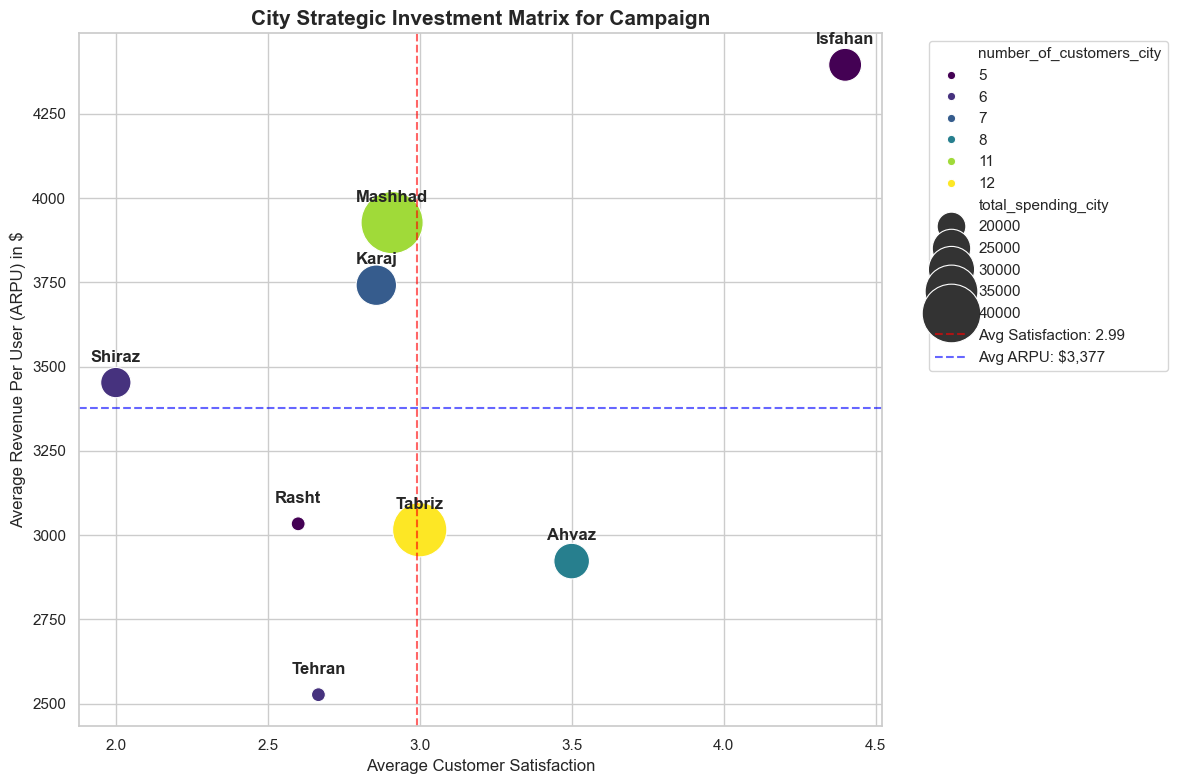

In [34]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(data=city_summary, x='avg_satisfaction_city', y='ARPU_city', size='total_spending_city',sizes=(100, 2000),
    hue='number_of_customers_city',palette='viridis',legend=True)

mean_x = city_summary['avg_satisfaction_city'].mean()
mean_y = city_summary['ARPU_city'].mean()
plt.axvline(mean_x, color='red', linestyle='--', alpha=0.6, label=f'Avg Satisfaction: {mean_x:.2f}')
plt.axhline(mean_y, color='blue', linestyle='--', alpha=0.6, label=f'Avg ARPU: ${mean_y:,.0f}')

for _, row in city_summary.iterrows():
    plt.annotate(
        row['city'],
        (row['avg_satisfaction_city'], row['ARPU_city']),
        textcoords="offset points",
        xytext=(0, 15),
        ha='center',
        fontweight='bold')

plt.title('City Strategic Investment Matrix for Campaign', fontsize=15, fontweight='bold')
plt.xlabel('Average Customer Satisfaction', fontsize=12)
plt.ylabel('Average Revenue Per User (ARPU) in $', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## سوال 3 : کدام مشتریان برای برنامه وفاداری اولویت دارند ؟

In [16]:
# cumstomer Analysis

customer_summary = df.groupby(['customer_id', 'first_name'], as_index=False).agg(

    total_spending = ('total_spending', 'sum'),
    number_of_customers = ('customer_id', 'nunique'),
    purchase_count = ('purchase_count', 'min'),
    last_purchase_days = ('last_purchase_days', 'min'),
    membership_tier = ('membership_tier', 'last'),
    satisfaction = ('satisfaction_score', 'min'),
    discount_used = ('discount_used', 'last'),
    device = ('device', 'last'),
    returned_items = ('returned_items', 'min'),
    payment_method = ('payment_method', 'last'),
    avg_order_value = ('avg_order_value', 'min'))
    
    

customer_summary['spending_per_purchase'] = customer_summary['total_spending'] / customer_summary['purchase_count']

customer_summary[['customer_id','first_name', 'spending_per_purchase', 
                  'last_purchase_days','purchase_count','satisfaction','total_spending','returned_items',
                  'membership_tier']].sort_values(by='returned_items',ascending=False).reset_index(drop=True).head()

,customer_id,first_name,spending_per_purchase,last_purchase_days,purchase_count,satisfaction,total_spending,returned_items,membership_tier
0,1015,Kimia,307.91,55,3,4,923.73,8,Gold
1,1027,Kimia,111.97,142,14,3,1567.58,8,Bronze
2,1045,Maryam,161.33,132,24,1,3871.92,8,Gold
3,1021,Amir,72.62,224,16,1,1161.92,8,Silver
4,1008,Reza,389.58,195,3,1,1168.74,8,VIP


In [17]:
# cumstomer Ranking by purchase count Score

q25, q50, q85, q100 = customer_summary['purchase_count'].quantile([0.25, 0.5, 0.85, 1])

conditions = [
    customer_summary['purchase_count'].lt(q25),
    customer_summary['purchase_count'].between(q25, q50, inclusive='left'),
    customer_summary['purchase_count'].between(q50, q85, inclusive='left'),
    customer_summary['purchase_count'].ge(q85)]

labels = ['low', 'medium', 'high', 'very_high']

customer_summary['purchase_count_status'] = np.select(conditions, labels, default='unknown')

purchase_count_map = {
    'low' : 0.2,
    'medium' : 0.5,
    'high' : 0.8,
    'very_high' : 1}

customer_summary['purchase_count_score'] = customer_summary['purchase_count_status'].map(purchase_count_map)

print(25*'--')
print('cumstomer Ranking by purchase count Score')
print(25*'--', '\n')

customer_summary[['first_name', 'purchase_count', 'purchase_count_status', 'purchase_count_score']].sort_values(
    by='purchase_count_score', ascending=False).reset_index(drop=True).head()
    

--------------------------------------------------
cumstomer Ranking by purchase count Score
-------------------------------------------------- 



,first_name,purchase_count,purchase_count_status,purchase_count_score
0,Ali,31,very_high,1.0
1,Maryam,31,very_high,1.0
2,Amir,35,very_high,1.0
3,Kimia,34,very_high,1.0
4,Amir,31,very_high,1.0


In [18]:
# cumstomer Ranking by last purchase days Score

q25, q50, q80, q100 = customer_summary ['last_purchase_days'].quantile([0.2, 0.5, 0.8, 1])

conditions = [
    customer_summary['last_purchase_days'] < q25,
    customer_summary['last_purchase_days'].between(q25, q50, inclusive='left'),
    customer_summary['last_purchase_days'].between(q50, q80, inclusive='left'),
    customer_summary['last_purchase_days'].ge(q80)]

labels = ['Recently_Active', 'Active', 'At_Risk', 'Inactive']

customer_summary['last_purchase_days_status'] = np.select(conditions, labels, default='unknown')

last_purchase_map = {
    'Recently_Active' : 1,
    'Active' : 0.7,
    'At_Risk' : 0.5,
    'Inactive' : 0.2}

customer_summary['last_purchase_days_score'] = customer_summary['last_purchase_days_status'].map(last_purchase_map)


print(25*'--')
print('City Ranking by Last Purchase Days Score')
print(25*'--', '\n')

customer_summary[['first_name', 'last_purchase_days', 'last_purchase_days_status',
              'last_purchase_days_score']].sort_values(by='last_purchase_days_score', ascending=False).reset_index(drop=True).head()

--------------------------------------------------
City Ranking by Last Purchase Days Score
-------------------------------------------------- 



,first_name,last_purchase_days,last_purchase_days_status,last_purchase_days_score
0,Reza,16,Recently_Active,1.0
1,Parsa,22,Recently_Active,1.0
2,Sina,40,Recently_Active,1.0
3,Kimia,4,Recently_Active,1.0
4,Maryam,82,Recently_Active,1.0


In [19]:
# cumstomer Ranking by total spending Score


q25, q50, q90, q100 = customer_summary ['total_spending'].quantile([0.2, 0.5, 0.9, 1])

conditions = [
    customer_summary['total_spending'] < q25,
    customer_summary['total_spending'].between(q25, q50, inclusive='left'),
    customer_summary['total_spending'].between(q50, q90, inclusive='left'),
    customer_summary['total_spending'].ge(q90)]

labels = ['low', 'medium', 'high', 'very_high']

customer_summary['total_spending_status'] = np.select(conditions, labels, default='unknown')

spending_per_purchase_map = {
    'very_high' : 1,
    'high' : 0.8,
    'medium' : 0.5,
    'low' : 0.2}

customer_summary['total_spending_score'] = customer_summary['total_spending_status'].map(spending_per_purchase_map)


print(25*'--')
print('cumstomer Ranking by spending per purchase Score')
print(25*'--', '\n')

customer_summary[['first_name', 'total_spending', 'total_spending_status', 'total_spending_score'
                 ]].sort_values(by='total_spending_score', ascending=False).reset_index(drop=True).head()

--------------------------------------------------
cumstomer Ranking by spending per purchase Score
-------------------------------------------------- 



,first_name,total_spending,total_spending_status,total_spending_score
0,Kimia,11615.42,very_high,1.0
1,Arash,11731.50,very_high,1.0
2,Ali,8898.55,very_high,1.0
3,Mina,14354.34,very_high,1.0
4,Maryam,13532.74,very_high,1.0


In [20]:
# cumstomer Ranking by membership tier Score

tier_map = {
    'VIP' : 1,
    'Gold' : 0.8,
    'Silver' : 0.5,
    'Bronze' : 0.3}

customer_summary['membership_tier_score'] = customer_summary['membership_tier'].map(tier_map)

customer_summary[['first_name', 'membership_tier', 'membership_tier_score']].sort_values(by='membership_tier_score', 
                                                                                          ascending=False).reset_index(drop=True).head()

,first_name,membership_tier,membership_tier_score
0,Reza,VIP,1.0
1,Parsa,VIP,1.0
2,Maryam,VIP,1.0
3,Neda,VIP,1.0
4,Sina,VIP,1.0


In [21]:
# customer Ranking by final_score_city

customer_summary['final_score_customer'] = (0.30 * customer_summary['last_purchase_days_score'] +
                                            0.40 * customer_summary['purchase_count_score'] + 
                                            0.05 * customer_summary['membership_tier_score'] +
                                            0.25 * customer_summary['total_spending_score'])
print(20*'--')
print('customer Ranking by final_score_loyality')
print(20*'--', '\n')

customer_summary[['customer_id', 'first_name', 'final_score_customer', 'purchase_count', 'last_purchase_days',
    'membership_tier','total_spending',]].sort_values(by='final_score_customer', ascending=False).reset_index(drop=True).head(10)



----------------------------------------
customer Ranking by final_score_loyality
---------------------------------------- 



,customer_id,first_name,final_score_customer,purchase_count,last_purchase_days,membership_tier,total_spending
0,1057,Maryam,0.965,31,82,Bronze,13532.74
1,1014,Reza,0.950,31,97,VIP,3353.89
2,1044,Mina,0.900,33,165,Gold,14354.34
3,1033,Neda,0.870,24,112,VIP,5521.20
4,1004,Sina,0.860,23,40,Gold,6121.45
5,1059,Ali,0.840,31,224,Gold,8898.55
6,1009,Kimia,0.825,34,232,Silver,11615.42
7,1023,Ali,0.825,31,170,Bronze,3851.44
8,1043,Kimia,0.795,23,54,VIP,1035.00
9,1001,Reza,0.795,17,16,VIP,2066.01


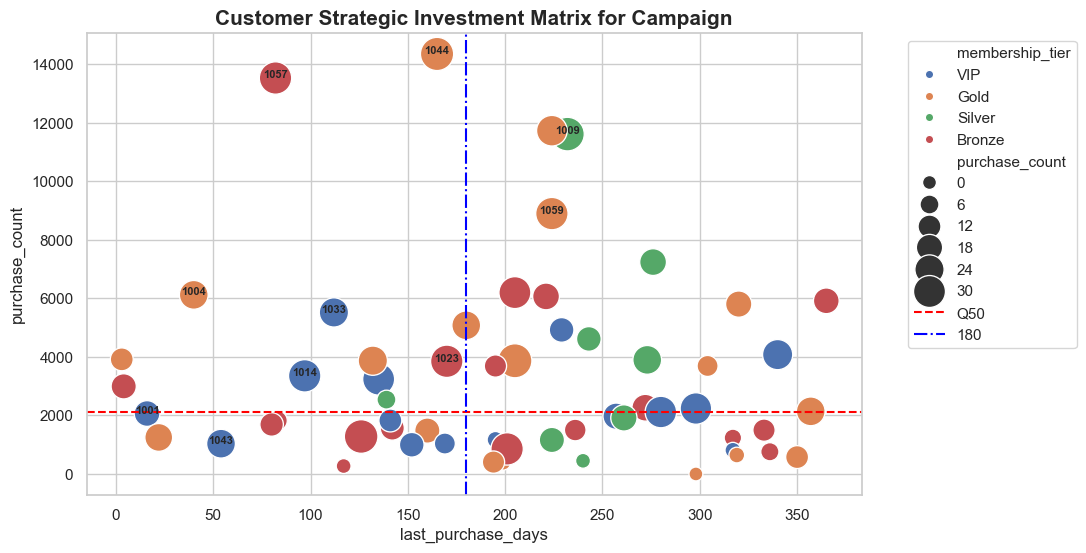

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
sns.set_theme(style="whitegrid")


sns.scatterplot(data=customer_summary,
                x='last_purchase_days',
                y='total_spending',
                size = 'purchase_count',
                hue = 'membership_tier',
                sizes=(100,600),
                legend=True)


for _, row in top10.iterrows():
    plt.annotate(row['customer_id'],
        (row['last_purchase_days'], row['total_spending']),
        textcoords="offset points",
        xytext=(0, 0),
        ha='center',
        fontsize=8,
        fontweight='bold')


ax.axhline(y=customer_summary['total_spending'].quantile(0.5), color='red', linestyle='--', label='Q50')
ax.axvline(x=180, color='blue', linestyle='-.', label='180')


plt.title('Customer Strategic Investment Matrix for Campaign', fontsize=15, fontweight='bold')
plt.xlabel('last_purchase_days', fontsize=12)
plt.ylabel('purchase_count', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

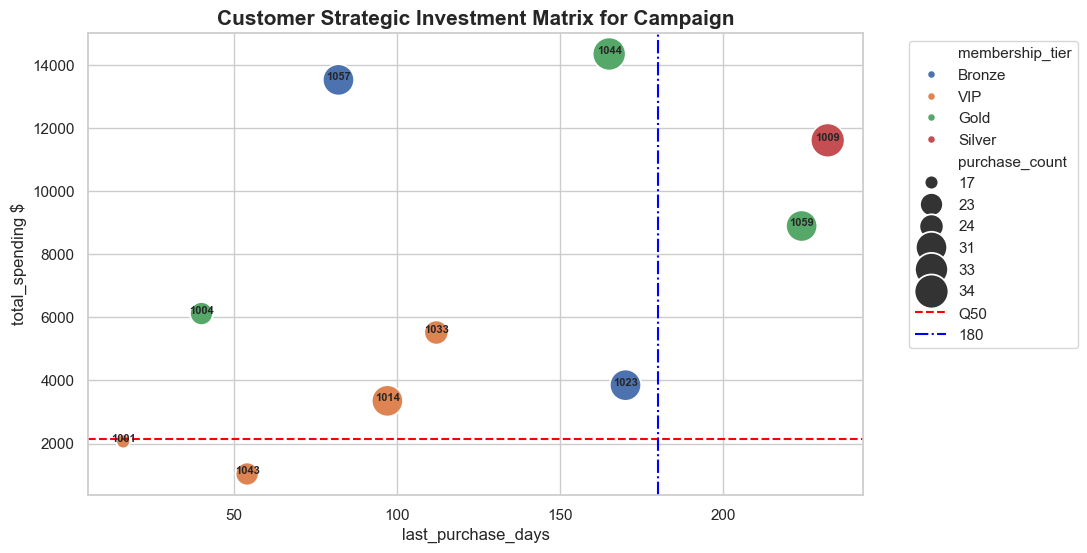

In [36]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
sns.set_theme(style="whitegrid")

top10 = customer_summary.sort_values(by='final_score_customer', ascending=False).head(10)
sns.scatterplot(data=top10,
                x='last_purchase_days',
                y='total_spending',
                size = 'purchase_count',
                hue = 'membership_tier',
                sizes=(100,600),
                legend=True)


for _, row in top10.iterrows():
    plt.annotate(
        row['customer_id'],
        (row['last_purchase_days'], row['total_spending']),
        textcoords="offset points",
        xytext=(0, 0),
        ha='center',
        fontsize=8,
        fontweight='bold')


ax.axhline(y=customer_summary['total_spending'].quantile(0.5), color='red', linestyle='--', label='Q50')
ax.axvline(x=180, color='blue', linestyle='-.', label='180')


plt.title('Customer Strategic Investment Matrix for Campaign', fontsize=15, fontweight='bold')
plt.xlabel('last_purchase_days', fontsize=12)
plt.ylabel('total_spending $', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## سوال 4 : کدام مشتریان با ارزش در معرض غیر فعال شدن هستند ؟

In [28]:

spending_threshold = customer_summary['total_spending'].quantile(0.75)  
recency_threshold = customer_summary['last_purchase_days'].quantile(0.75)

at_risk_vips = customer_summary.query(
    'total_spending >= @spending_threshold and last_purchase_days >= @recency_threshold').sort_values(by='total_spending', ascending=False)

print( f'Vip customers at risk: {len(at_risk_vips)} in {len(customer_summary)}')
display(at_risk_vips[['customer_id', 'first_name', 'total_spending', 'last_purchase_days', 'satisfaction',
                      'final_score_customer']])

Vip customers at risk: 3 in 60


,customer_id,first_name,total_spending,last_purchase_days,satisfaction,final_score_customer
9,1010,Arash,7241.47,276,1,0.745
34,1035,Arash,5918.21,365,3,0.595
52,1053,Sina,5805.54,320,1,0.620


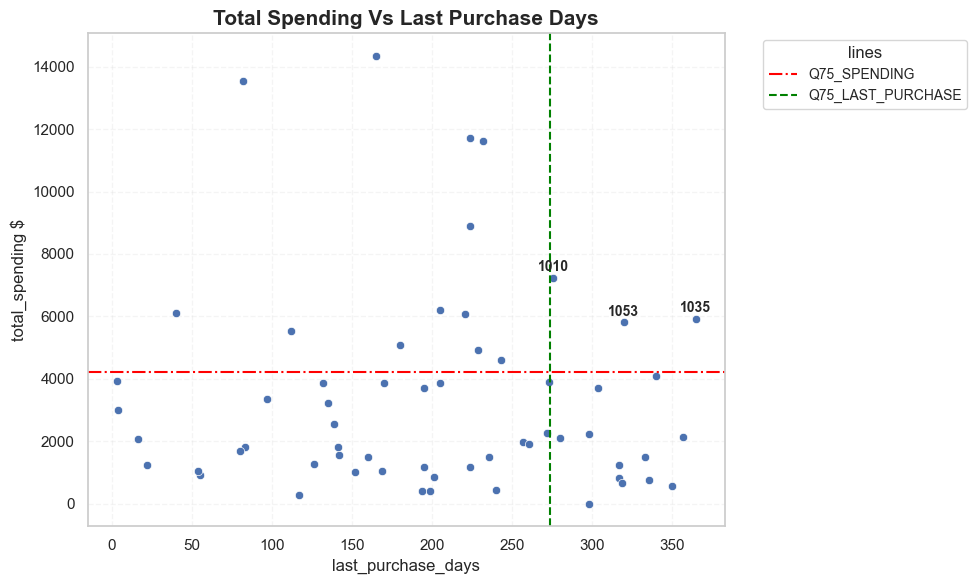

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
sns.set_theme(style="whitegrid")


sns.scatterplot(data=customer_summary, x='last_purchase_days', y='total_spending', ax=ax, sizes=(100,200))

for _, row in at_risk_vips.iterrows():
    plt.annotate(
        row['customer_id'],
        (row['last_purchase_days'], row['total_spending']),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center',
        fontsize=10,
        fontweight='bold')

    
ax.axhline(y=spending_threshold, color='red', linestyle='-.', label='Q75_SPENDING')
ax.axvline(x=recency_threshold, color='green', linestyle='--', label='Q75_LAST_PURCHASE')


# تنظیمات نمودار
ax.grid(True, linestyle="--",alpha=0.2)

    
# تنظیمات لیبل ها

plt.title('Total Spending Vs Last Purchase Days', fontsize=15, fontweight='bold')
plt.xlabel('last_purchase_days', fontsize=12)
plt.ylabel('total_spending $', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='lines', fontsize=10)
plt.tight_layout()
plt.show()


In [30]:
assert not customer_summary.empty, "No customers available"
assert customer_summary["last_purchase_days"].notna().all(), ("Missing last-purchase values")

# Assumes customer_summary contains one row per customer
recency_threshold = customer_summary["last_purchase_days"].quantile(0.75)
inactive_mask = (customer_summary["last_purchase_days"] > recency_threshold)
inactive_customer_rate = inactive_mask.mean() * 100

print(f"Inactivity threshold: {recency_threshold:.2f} days")
print(f"Inactive Customer Rate: {inactive_customer_rate:.2f}%")

Inactivity threshold: 273.75 days
Inactive Customer Rate: 25.00%


## سوال 5 : تخفیف، دستگاه و روش پرداخت با رفتار مشتری چه ارتباطی دارد ؟

In [31]:
discount_summary = customer_summary.groupby('discount_used', as_index=False).agg(
    avg_total_spending = ('total_spending', 'mean'),
    total_spending = ('total_spending', 'sum'),
    avg_purchase_count = ('purchase_count', 'mean'),
    purchase_count = ('purchase_count', 'sum'),
    avg_returned_items = ('returned_items', 'mean'),
    return_count = ('returned_items', 'sum'),
    avg_satisfaction = ('satisfaction', 'mean'),
    avg_order_value = ('avg_order_value', 'mean'),
    num_of_customers = ('number_of_customers', 'sum'))

display(discount_summary.head(5))

,discount_used,avg_total_spending,total_spending,avg_purchase_count,purchase_count,avg_returned_items,return_count,avg_satisfaction,avg_order_value,num_of_customers
0,No,3736.741176,127049.20,17.294118,588,4.264706,145,2.764706,220.700588,34
1,Yes,2882.174231,74936.53,17.500000,455,4.076923,106,3.269231,203.291154,26


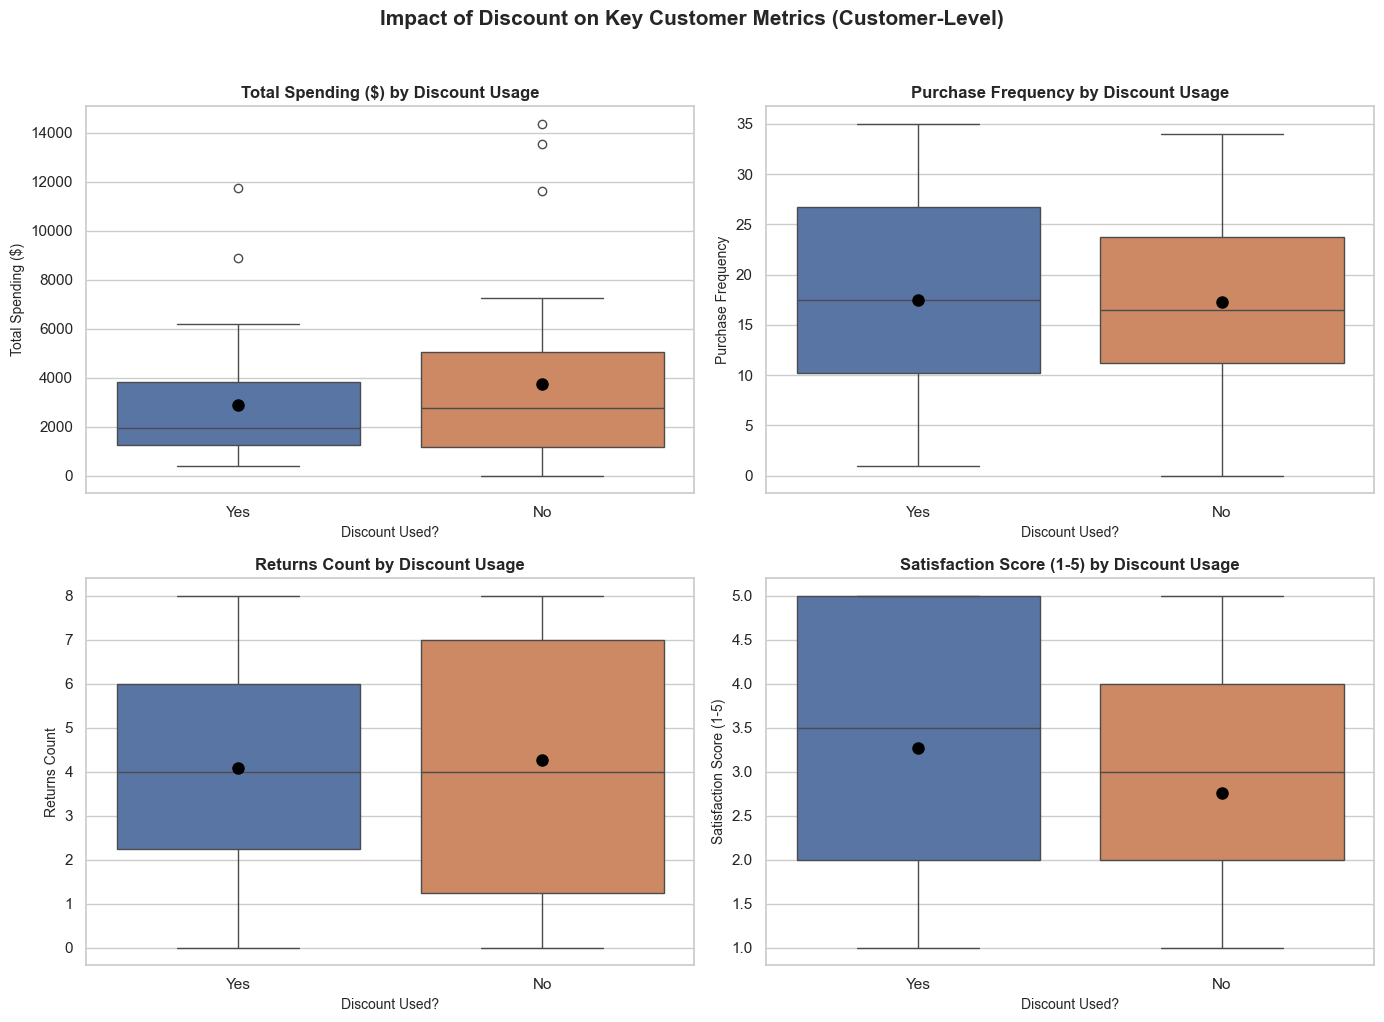

In [101]:

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

metrics = [
    ('total_spending', 'Total Spending ($)', axes[0, 0]),
    ('purchase_count', 'Purchase Frequency', axes[0, 1]),
    ('returned_items', 'Returns Count', axes[1, 0]),
    ('satisfaction', 'Satisfaction Score (1-5)', axes[1, 1])]


for col, title, ax in metrics:
    sns.boxplot(
        data=customer_summary,
        x='discount_used', 
        y=col,
        hue='discount_used',  
        ax=ax,
        legend=False,
        showmeans=True,
        meanprops={
            'marker': 'o',
            'markerfacecolor': 'black',
            'markeredgecolor': 'black',
            'markersize': 8,},)

    ax.set_title(f'{title} by Discount Usage', fontsize=12, fontweight='bold')
    ax.set_xlabel('Discount Used?', fontsize=10)
    ax.set_ylabel(title, fontsize=10)

plt.suptitle('Impact of Discount on Key Customer Metrics (Customer-Level)',fontsize=15,fontweight='bold',y=1.02,)
plt.tight_layout()
plt.show()

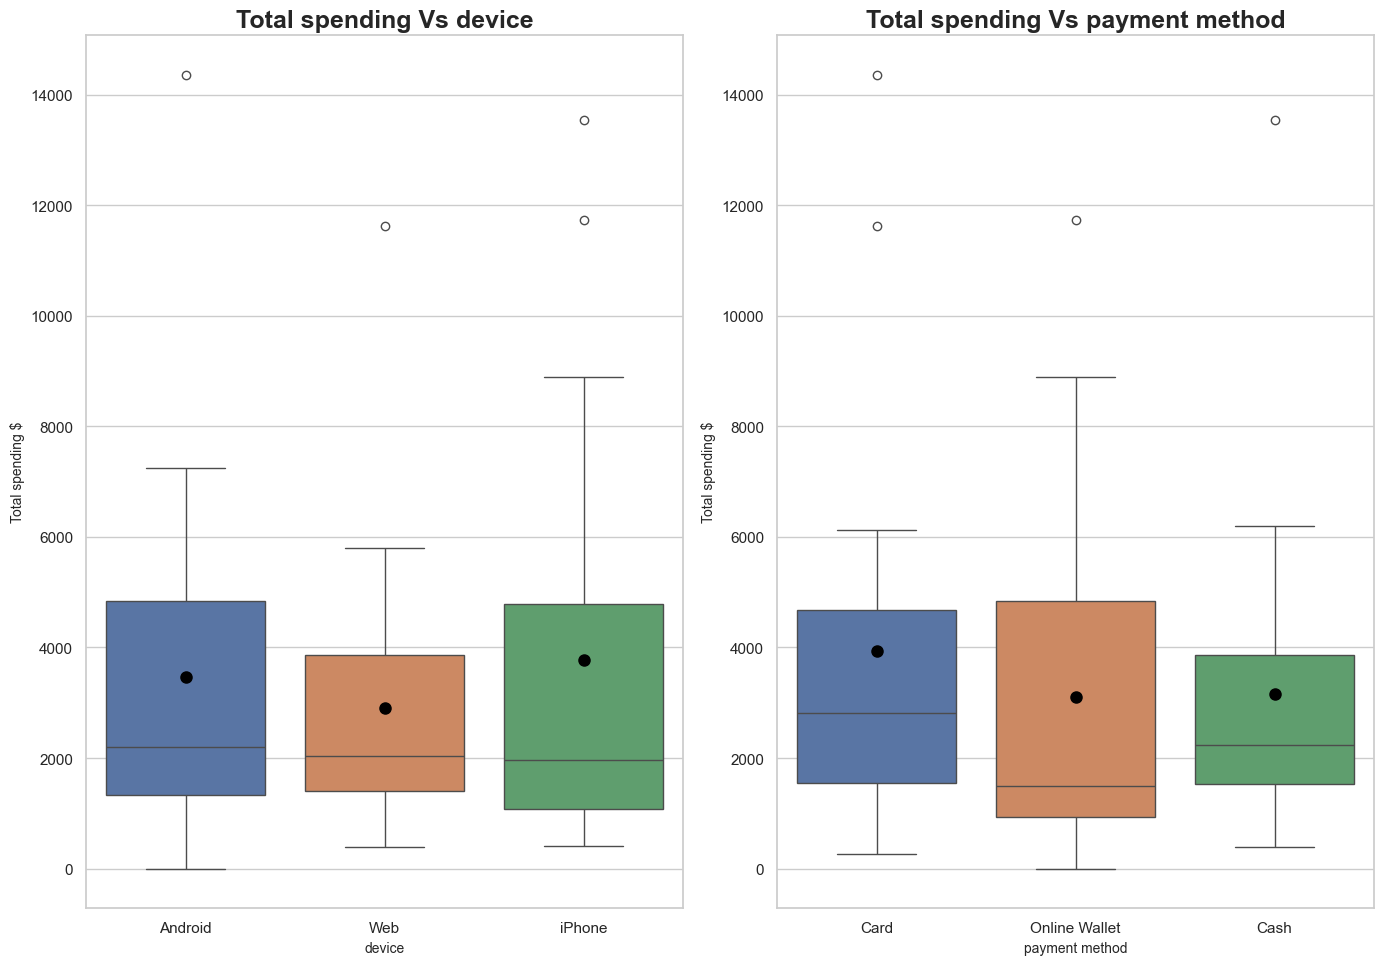

In [102]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 10))

metrics = [('device', 'device', axes[0]),('payment_method', 'payment method', axes[1])]


for col, title, ax in metrics:
    sns.boxplot(
        data=customer_summary,
        x=col,  
        y='total_spending',
        hue=col,  
        ax=ax,
        legend=False,
        showmeans=True,
        meanprops={
            'marker': 'o',
            'markerfacecolor': 'black',
            'markeredgecolor': 'black',
            'markersize': 8,},)

    ax.set_title(f'Total spending Vs {title}', fontsize=18, fontweight='bold')
    ax.set_xlabel(title, fontsize=10)
    ax.set_ylabel('Total spending $', fontsize=10)

plt.suptitle('',fontsize=15,fontweight='bold',y=1.02,)
plt.tight_layout()
plt.show()

In [103]:
import numpy as np
import pandas as pd
from scipy import stats

# اگر پکیج نصب نیست: pip install scikit-posthocs
try:
    import scikit_posthocs as sp

    POSTHOC_AVAILABLE = True
except ImportError:
    POSTHOC_AVAILABLE = False


def run_kruskal_test(
    df: pd.DataFrame, group_col: str, target_col: str = "total_spending"
):
    print("=" * 65)
    print(f"Running Kruskal-Wallis Test: [{target_col}] across [{group_col}]")
    print("=" * 65)

    # 1. آماده‌سازی و حذف مقادیر گمشده
    clean_df = df[[group_col, target_col]].dropna()
    groups = [
        group[target_col].values
        for _, group in clean_df.groupby(group_col)
        if len(group) > 0
    ]
    unique_groups = clean_df[group_col].unique()

    # 2. خلاصه آماری گروه‌ها
    summary = clean_df.groupby(group_col)[target_col].agg(
        ["count", "median", "mean"]
    )
    print("\n--- Group Summary ---")
    print(summary.round(2))
    print("-" * 50)

    # 3. آزمون Kruskal-Wallis
    h_stat, p_value = stats.kruskal(*groups)
    print(f"H-Statistic: {h_stat:.4f}")
    print(f"p-value:     {p_value:.5e}")
    print("-" * 50)

    # 4. تفسیر نتیجه
    alpha = 0.05
    if p_value < alpha:
        print(f"Result: STATISTICALLY SIGNIFICANT (p < {alpha})")
        print(
            f"Insight: Group differences in [{group_col}] are NOT random noise."
        )

        # 5. آزمون تعقیبی دان در صورت معنادار بودن
        if POSTHOC_AVAILABLE and len(unique_groups) > 2:
            print(
                "\n--- Dunn Post-Hoc Pairwise Test (p-values with Bonferroni) ---"
            )
            dunn = sp.posthoc_dunn(
                clean_df, val_col=target_col, group_col=group_col, p_adjust="bonferroni"
            )
            print(dunn.round(4))
            print("Note: Values < 0.05 indicate significant differences.")
        elif not POSTHOC_AVAILABLE:
            print("\nTo see pairwise differences: pip install scikit-posthocs")
    else:
        print(f"Result: NOT SIGNIFICANT (p >= {alpha})")
        print(
            f"Insight: No statistically significant difference across [{group_col}]."
        )

    print("=" * 65 + "\n")
    return h_stat, p_value


# --- فراخوانی برای دو ستون مورد نظر ---
# اگر نام ستون‌هایت دقیقاً این نیست، نام آن‌ها را عوض کن:
h_device, p_device = run_kruskal_test(
    df, group_col="device", target_col="total_spending"
)
h_payment, p_payment = run_kruskal_test(
    df, group_col="payment_method", target_col="total_spending"
)


Running Kruskal-Wallis Test: [total_spending] across [device]

--- Group Summary ---
         count   median     mean
device                          
Android     22  2190.52  3459.07
Web         20  2028.06  2897.76
iPhone      18  1964.46  3773.94
--------------------------------------------------
H-Statistic: 0.2634
p-value:     8.76612e-01
--------------------------------------------------
Result: NOT SIGNIFICANT (p >= 0.05)
Insight: No statistically significant difference across [device].

Running Kruskal-Wallis Test: [total_spending] across [payment_method]

--- Group Summary ---
                count   median     mean
payment_method                         
Card               18  2808.96  3929.00
Cash               19  2237.35  3150.58
Online Wallet      23  1497.87  3104.46
--------------------------------------------------
H-Statistic: 1.3581
p-value:     5.07110e-01
--------------------------------------------------
Result: NOT SIGNIFICANT (p >= 0.05)
Insight: No statisticall

In [104]:
# Check the values first
print(df["discount_used"].value_counts(dropna=False))

# Validate customer-level data
assert df["customer_id"].notna().all(), "Missing customer IDs"
assert df["customer_id"].is_unique, "Multiple rows per customer"
assert df["discount_used"].notna().all(), "Missing discount values"
assert df["discount_used"].isin(['No', 'Yes']).all(), "Expected True/False or 1/0"

discount_usage_rate = df["discount_used"].eq('Yes').mean() * 100

print(f"Discount Usage Rate: {discount_usage_rate:.2f}%")

discount_used
No     34
Yes    26
Name: count, dtype: int64
Discount Usage Rate: 43.33%


## سوال 6 : گزارش 5 دقیقه ای مدیر عامل را بسازید ؟

In [105]:
kpi_summary = pd.Series({
    "یکتا مشتریان تعداد": df["customer_id"].nunique(),
    "مشتریان خرید مجموع": df["total_spending"].sum(),
    "مشتری هر خرید مجموع میانگین": df["total_spending"].mean(),
    "خرید تعداد میانگین": df["purchase_count"].mean(),
    "رضایت میانگین": df["satisfaction_score"].mean(),
    "مرجوعشده کاالهای مجموع": df["returned_items"].sum()}).round(2)
display(kpi_summary)

یکتا مشتریان تعداد                 60.00
مشتریان خرید مجموع             201985.73
مشتری هر خرید مجموع میانگین      3366.43
خرید تعداد میانگین                 17.38
رضایت میانگین                       2.98
مرجوعشده کاالهای مجموع            251.00
dtype: float64

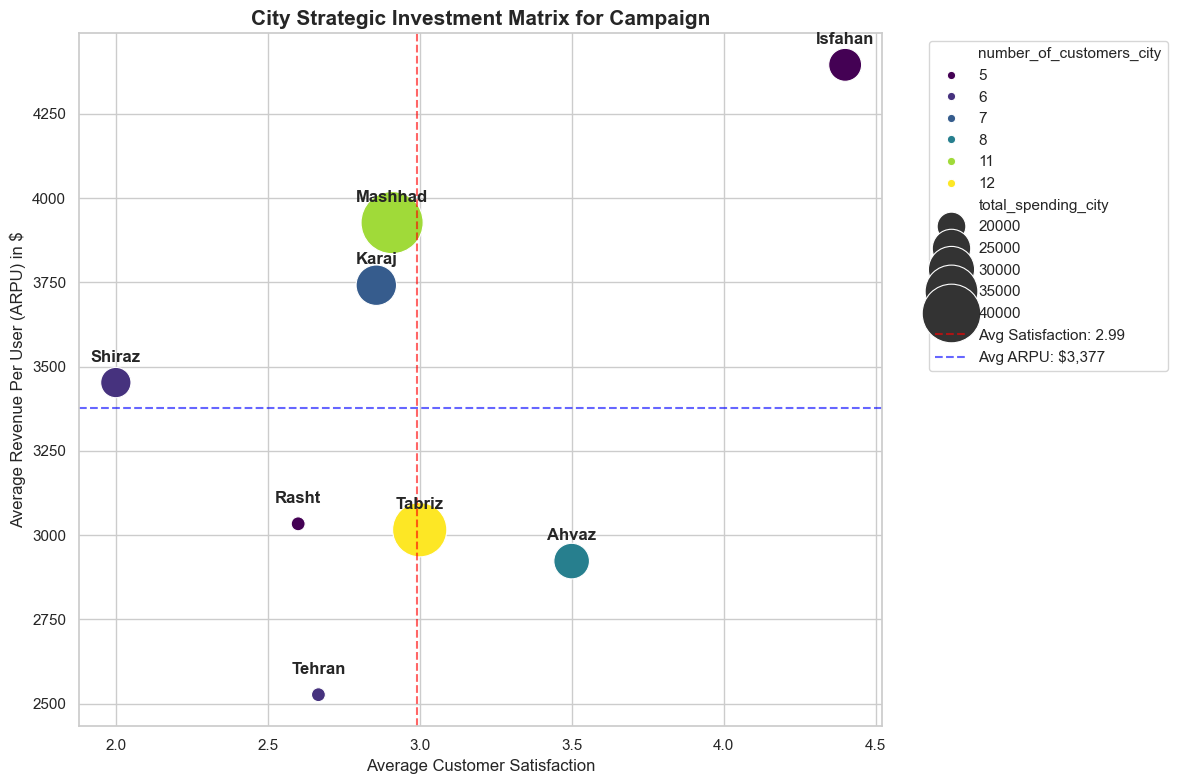

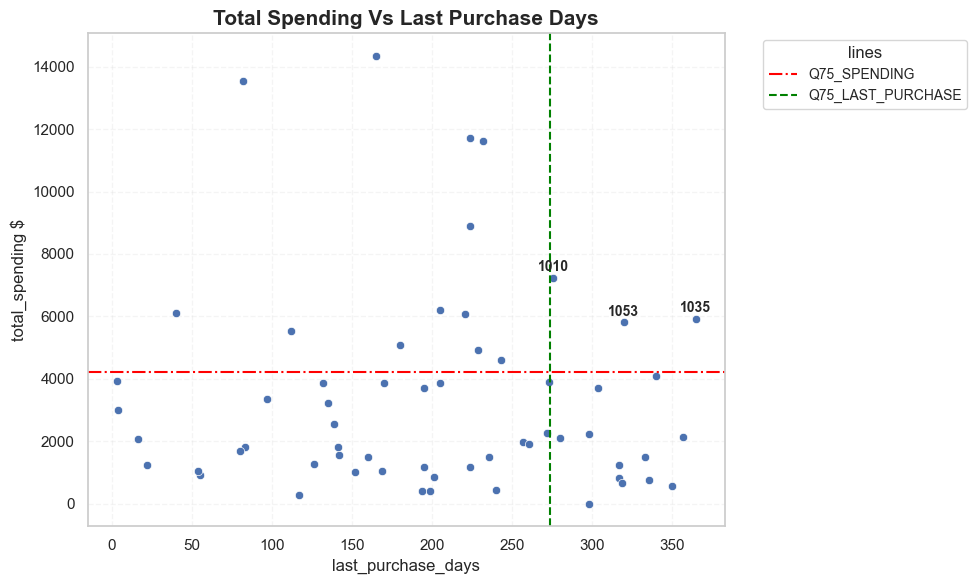

NameError: name 'palette_dict' is not defined

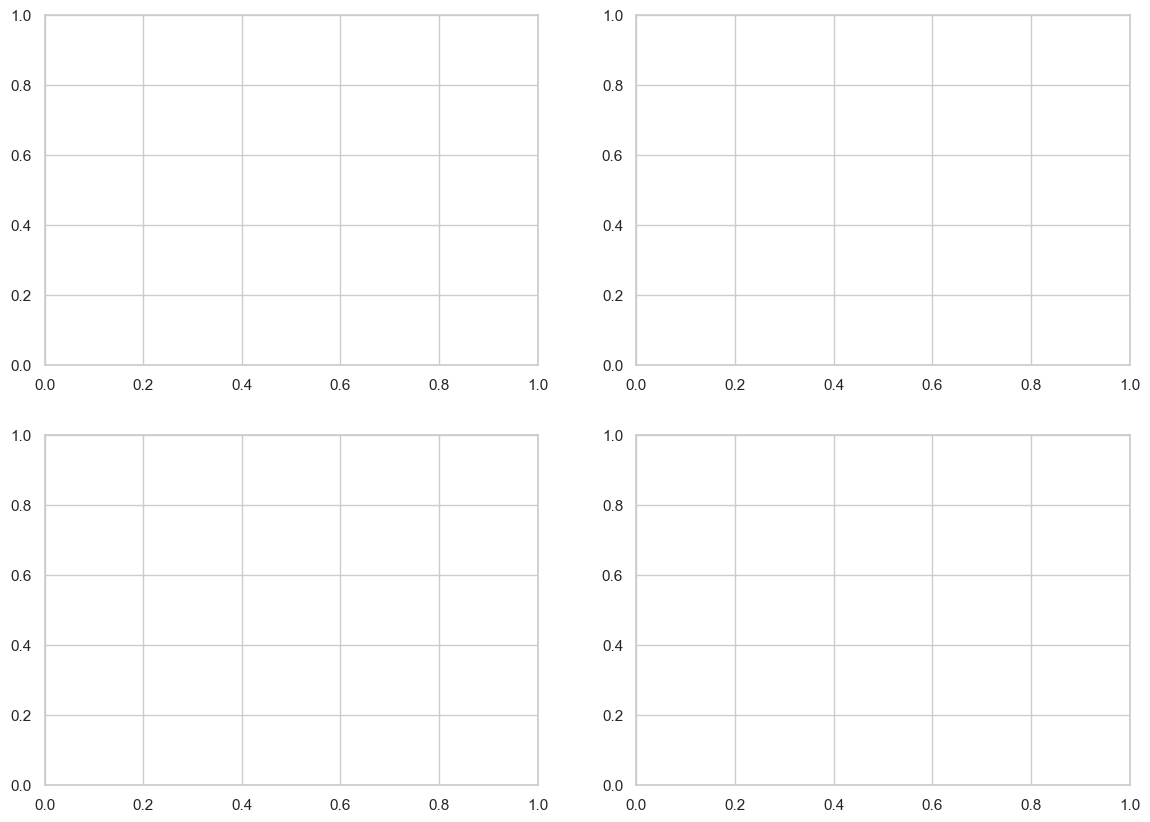

In [108]:
# نمودار شماره 1

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(data=city_summary, x='avg_satisfaction_city', y='ARPU_city', size='total_spending_city',sizes=(100, 2000),
    hue='number_of_customers_city',palette='viridis',legend=True)

mean_x = city_summary['avg_satisfaction_city'].mean()
mean_y = city_summary['ARPU_city'].mean()
plt.axvline(mean_x, color='red', linestyle='--', alpha=0.6, label=f'Avg Satisfaction: {mean_x:.2f}')
plt.axhline(mean_y, color='blue', linestyle='--', alpha=0.6, label=f'Avg ARPU: ${mean_y:,.0f}')

for _, row in city_summary.iterrows():
    plt.annotate(
        row['city'],
        (row['avg_satisfaction_city'], row['ARPU_city']),
        textcoords="offset points",
        xytext=(0, 15),
        ha='center',
        fontweight='bold')

plt.title('City Strategic Investment Matrix for Campaign', fontsize=15, fontweight='bold')
plt.xlabel('Average Customer Satisfaction', fontsize=12)
plt.ylabel('Average Revenue Per User (ARPU) in $', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
print(3*'\n')



#نمودار شماره 2

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
sns.set_theme(style="whitegrid")


sns.scatterplot(data=customer_summary, x='last_purchase_days', y='total_spending', ax=ax, sizes=(100,200))

for _, row in at_risk_vips.iterrows():
    plt.annotate(
        row['customer_id'],
        (row['last_purchase_days'], row['total_spending']),
        textcoords="offset points",
        xytext=(0, 5),
        ha='center',
        fontsize=10,
        fontweight='bold')

    
ax.axhline(y=spending_threshold, color='red', linestyle='-.', label='Q75_SPENDING')
ax.axvline(x=recency_threshold, color='green', linestyle='--', label='Q75_LAST_PURCHASE')


# تنظیمات نمودار
ax.grid(True, linestyle="--",alpha=0.2)

    
# تنظیمات لیبل ها

plt.title('Total Spending Vs Last Purchase Days', fontsize=15, fontweight='bold')
plt.xlabel('last_purchase_days', fontsize=12)
plt.ylabel('total_spending $', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='lines', fontsize=10)
plt.tight_layout()
plt.show()
print(3*'\n')




# نمودار شماره 3

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

metrics = [
    ('total_spending', 'Total Spending ($)', axes[0, 0]),
    ('purchase_count', 'Purchase Frequency', axes[0, 1]),
    ('returned_items', 'Returns Count', axes[1, 0]),
    ('satisfaction', 'Satisfaction Score (1-5)', axes[1, 1])]


for col, title, ax in metrics:
    sns.boxplot(
        data=customer_summary,
        x='discount_used',  
        y=col,
        hue='discount_used',  
        palette=palette_dict,
        ax=ax,
        legend=False,
        showmeans=True,
        meanprops={
            'marker': 'o',
            'markerfacecolor': 'black',
            'markeredgecolor': 'black',
            'markersize': 8,},)

    ax.set_title(f'{title} by Discount Usage', fontsize=12, fontweight='bold')
    ax.set_xlabel('Discount Used?', fontsize=10)
    ax.set_ylabel(title, fontsize=10)

plt.suptitle('Impact of Discount on Key Customer Metrics (Customer-Level)',fontsize=15,fontweight='bold',y=1.02,)
plt.tight_layout()
plt.show()

## SAVE RESULTS

In [ ]:
# نهایی گزارش برای اصلی جدولهای ذخیره

with pd.ExcelWriter(r'customer_analytics_results.xlsx') as writer:
    kpi_summary.to_excel(writer, sheet_name='KPI')
    city_summary.to_excel(writer, sheet_name='City Analysis', index=False)
    customer_summary.to_excel(writer, sheet_name='customer summary', index=False)
    customer_summary1.to_excel(writer, sheet_name='customer summary 1', index=False)
    at_risk_vips.to_excel(writer, sheet_name='At Risk Customers', index=False)
    discount_summary.to_excel(writer, sheet_name='Discount Analysis', index=False)
print('فایل customer_analytics_results.xlsx شد ذخیره.')